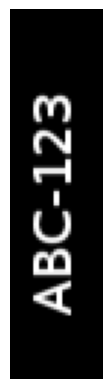

In [197]:
from skimage.io import imread
from matplotlib import pyplot as plt
import numpy as np

im = imread('letters_numbers.tif')

invert = False  # set to True to invert the image
if invert:
    im = im.max() - im

rotate = True  # set to True to rotate 90 degrees
if rotate:
    im = np.rot90(im)

plt.imshow(im, cmap='gray')
plt.axis('off')
plt.show()

PSF type: Custom
PSF sum: 1.0000


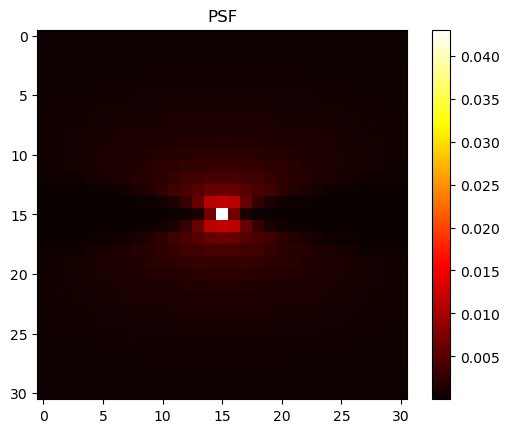

In [198]:
from scipy.ndimage import gaussian_filter

use_gaussian = False  # set to True to use Gaussian PSF
use_gibson_lanni = True
gaussian_sigma = 1.5
psf_size = 7

if use_gaussian:
    # create 2D Gaussian PSF
    psf_2d = np.zeros((psf_size, psf_size), dtype=np.float32)
    psf_2d[psf_size // 2, psf_size // 2] = 1.0
    psf_2d = gaussian_filter(psf_2d, sigma=gaussian_sigma)
elif use_gibson_lanni:
    from tnia.deconvolution.psfs import gibson_lanni_3D

    xy_psf_dim = 31
    NA = 1.4
    x_voxel_size = 0.185
    z_voxel_size = 0.5
    z_psf_dim = 31
    ni = 1.51
    ns = 1.51
    defocus = 0
    wl = 0.5

    psf = gibson_lanni_3D(NA, ni, ns, x_voxel_size, z_voxel_size, xy_psf_dim, z_psf_dim, defocus, wl, use_psfm=True)
    psf_2d = psf.sum(axis=2).squeeze()
    
else:
    # define custom PSF: top and bottom rows filled, middle rows sparse
    psf_2d = np.array([
        [1/7, 1/7, 1/7, 1/7, 1/7, 1/7, 1/7],
        [0,   1/5, 1/5, 1/5, 1/5, 1/5, 0  ],
        [0,   0,   1/3, 1/3, 1/3, 0,   0  ],
        [0,   0,   0,  1,  0, 0,   0  ],
        [0,   0,   1/3, 1/3, 1/3, 0,   0  ],
        [0,   1/5, 1/5, 1/5, 1/5, 1/5, 0  ],
        [1/7, 1/7, 1/7, 1/7, 1/7, 1/7, 1/7],
    ], dtype=np.float32)

psf_2d = psf_2d / psf_2d.sum()
print(f'PSF type: {"Gaussian (sigma={})".format(gaussian_sigma) if use_gaussian else "Custom"}')
print(f'PSF sum: {psf_2d.sum():.4f}')

plt.imshow(psf_2d, cmap='hot', interpolation='nearest')
plt.title('PSF')
plt.colorbar()
plt.show()

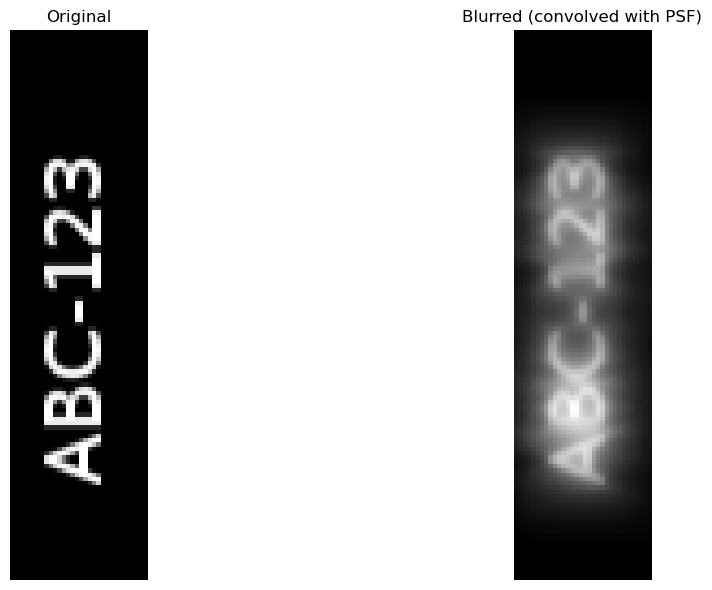

In [199]:
from scipy.signal import convolve2d

psf_2d_norm = psf_2d / psf_2d.sum()

blurred = convolve2d(im.astype(np.float32), psf_2d_norm, mode='same', boundary='fill', fillvalue=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(im, cmap='gray', interpolation='nearest')
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(blurred, cmap='gray', interpolation='nearest')
axes[1].set_title('Blurred (convolved with PSF)')
axes[1].axis('off')
plt.tight_layout()
plt.show()


In [200]:
from tnia.deconvolution.richardson_lucy import richardson_lucy_cp

iterations = 100

Input size: (32,), PSF size: (3,)

0 10 20 30 40 50 60 70 80 90 
Input size: (32,), PSF size: (3,)

0 10 20 30 40 50 60 70 80 90 
Input size: (32,), PSF size: (3,)

0 10 20 30 40 50 60 70 80 90 
Input size: (32,), PSF size: (3,)

0 10 20 30 40 50 60 70 80 90 
Input size: (32,), PSF size: (3,)

0 10 20 30 40 50 60 70 80 90 
Input size: (32,), PSF size: (3,)

0 10 20 30 40 50 60 70 80 90 
Input size: (32,), PSF size: (3,)

0 10 20 30 40 50 60 70 80 90 
Input size: (32,), PSF size: (3,)

0 10 20 30 40 50 60 70 80 90 
Input size: (32,), PSF size: (3,)

0 10 20 30 40 50 60 70 80 90 
Input size: (32,), PSF size: (3,)

0 10 20 30 40 50 60 70 80 90 
Input size: (32,), PSF size: (3,)

0 10 20 30 40 50 10 20 30 40 50 60 70 80 90 
Input size: (32,), PSF size: (3,)

0 10 20 30 40 50 60 70 80 90 
Input size: (32,), PSF size: (3,)

0 10 20 30 40 50 60 70 80 90 
Input size: (32,), PSF size: (3,)

0 10 20 30 40 50 60 70 80 90 
Input size: (32,), PSF size: (3,)

0 10 20 30 40 50 60 70 80 90 
Input size

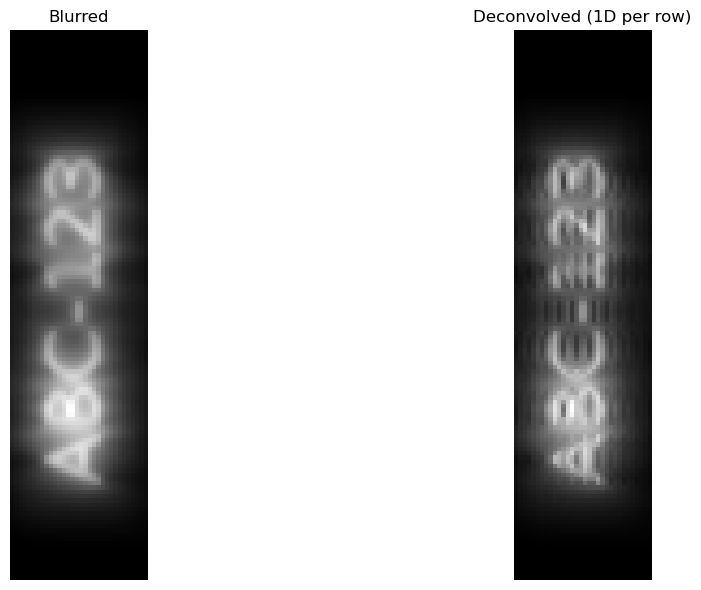

Decon image shape: (128, 32)


In [201]:
psf_1d = np.array([1/3, 1/3, 1/3])

decon_rows = []
for row in blurred:
    decon_row = richardson_lucy_cp(row, psf_1d, iterations, noncirc=True)
    decon_rows.append(decon_row)

decon_image_1d_1d = np.stack(decon_rows, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(blurred, cmap='gray', interpolation='nearest')
axes[0].set_title('Blurred')
axes[0].axis('off')
axes[1].imshow(decon_image_1d_1d, cmap='gray', interpolation='nearest')
axes[1].set_title('Deconvolved (1D per row)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print("Decon image shape:", decon_image_1d_1d.shape)

1.0
Input size: (1, 32), PSF size: (31, 31)
Input is 2D, PSF is 2D

0 10 20 30 40 50 60 70 80 90 
1.0
Input size: (1, 32), PSF size: (31, 31)
Input is 2D, PSF is 2D

0 10 20 30 40 50 60 70 80 90 
1.0
Input size: (1, 32), PSF size: (31, 31)
Input is 2D, PSF is 2D

0 10 20 30 40 50 60 70 80 90 
1.0
Input size: (1, 32), PSF size: (31, 31)
Input is 2D, PSF is 2D

0 10 20 30 40 50 60 70 30 40 50 60 70 80 90 
1.0
Input size: (1, 32), PSF size: (31, 31)
Input is 2D, PSF is 2D

0 10 20 30 40 50 60 70 80 90 
1.0
Input size: (1, 32), PSF size: (31, 31)
Input is 2D, PSF is 2D

0 10 20 30 40 50 60 70 80 90 
1.0
Input size: (1, 32), PSF size: (31, 31)
Input is 2D, PSF is 2D

0 10 20 30 40 50 60 70 80 90 
1.0
Input size: (1, 32), PSF size: (31, 31)
Input is 2D, PSF is 2D

0 80 90 
1.0
Input size: (1, 32), PSF size: (31, 31)
Input is 2D, PSF is 2D

0 10 20 30 40 50 60 70 80 90 
1.0
Input size: (1, 32), PSF size: (31, 31)
Input is 2D, PSF is 2D

0 10 20 30 40 50 60 70 80 90 
1.0
Input size: (1, 32), P

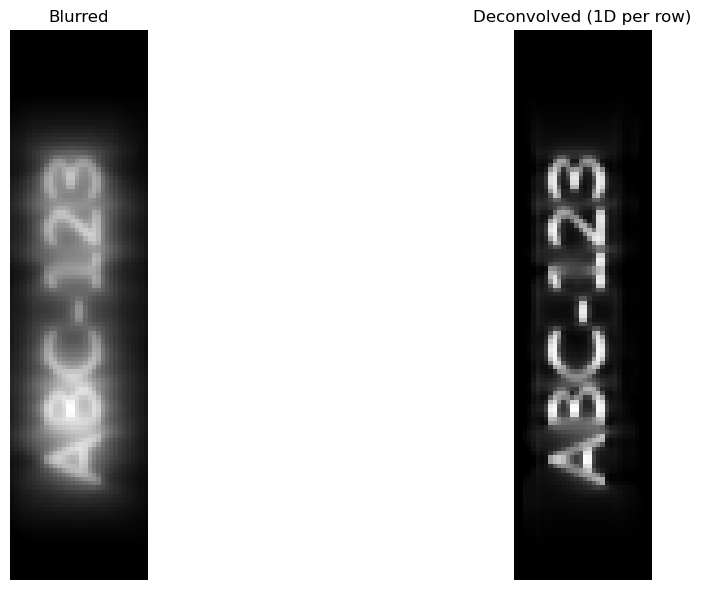

Decon image shape: (128, 32)


In [202]:

decon_rows = []
for row in blurred:
    # add trivial dimension
    row = row[np.newaxis, ...]
    print(psf_2d.sum())
    decon_row = richardson_lucy_cp(row, psf_2d, iterations, noncirc=True)
    #if decon_row.sum() > 0:
    #    decon_row = decon_row * (row.sum()/decon_row.sum())
    decon_rows.append(decon_row)

decon_image_1d_2d = np.stack(decon_rows, axis=0)
decon_image_1d_2d = decon_image_1d_2d.squeeze(axis=1)  # remove trivial dimension


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(blurred, cmap='gray', interpolation='nearest')
axes[0].set_title('Blurred')
axes[0].axis('off')
axes[1].imshow(decon_image_1d_2d, cmap='gray', interpolation='nearest')
axes[1].set_title('Deconvolved (1D per row)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print("Decon image shape:", decon_image_1d_2d.shape)

Input size: (128, 32), PSF size: (31, 31)
Input is 2D, PSF is 2D

0 10 20 30 40 50 60 70 80 90 


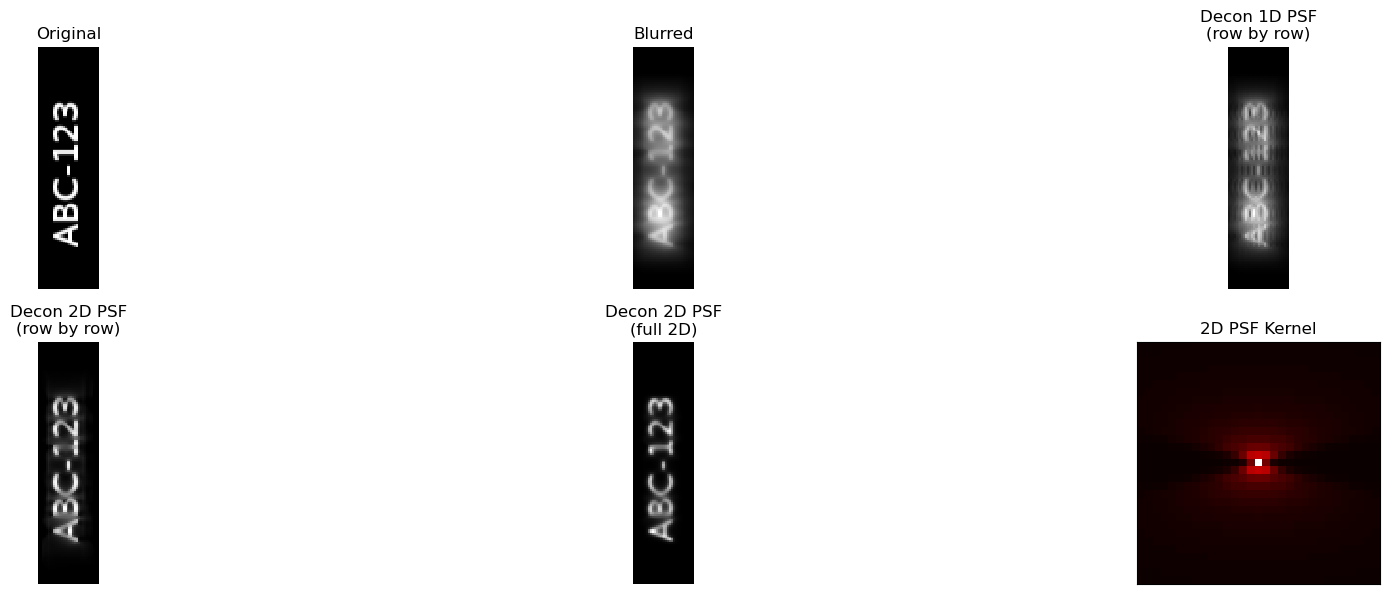

In [203]:
decon_2d = richardson_lucy_cp(blurred, psf_2d, iterations, noncirc=True)

fig, axes = plt.subplots(3, 3, figsize=(18, 9))
axes = axes.flatten()

images = [im, blurred, decon_image_1d_1d, decon_image_1d_2d, decon_2d]
titles = ['Original', 'Blurred', 'Decon 1D PSF\n(row by row)', 'Decon 2D PSF\n(row by row)', 'Decon 2D PSF\n(full 2D)']

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray', interpolation='nearest')
    ax.set_title(title)
    ax.axis('off')

# show PSF kernel small and square, centered in its subplot
psf_ax = axes[len(images)]
psf_ax.set_aspect('equal')
psf_ax.imshow(psf_2d_norm, cmap='hot', interpolation='nearest')
psf_ax.set_title('2D PSF Kernel')
psf_ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

for ax in axes[len(images)+1:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

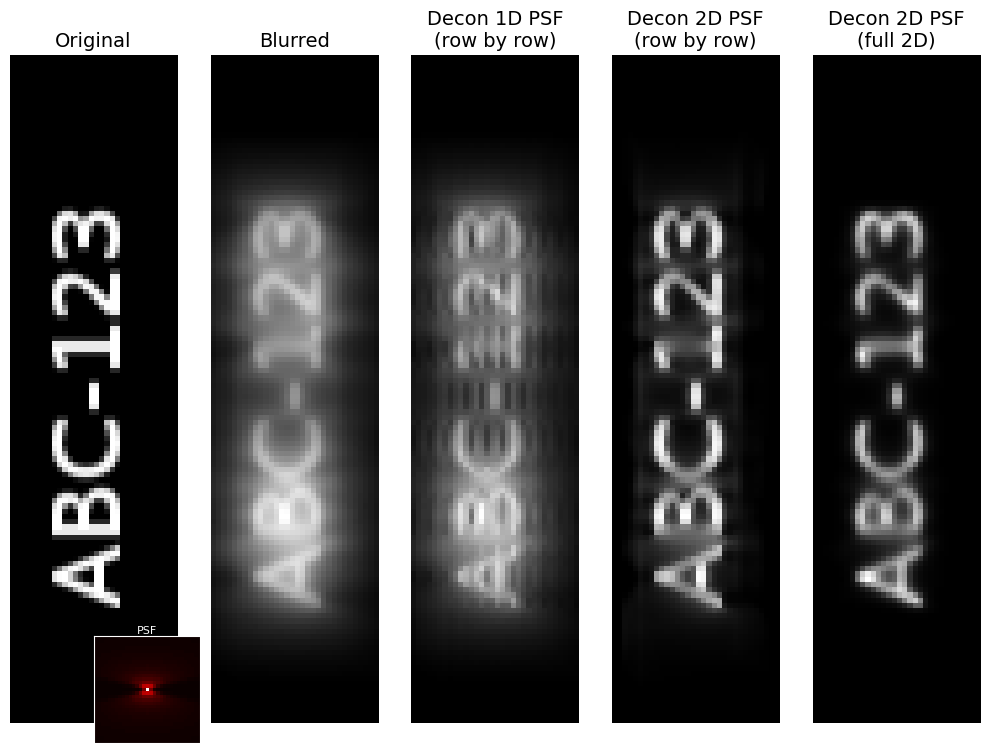

In [215]:
images = [im, blurred, decon_image_1d_1d, decon_image_1d_2d, decon_2d]
titles = ['Original', 'Blurred', 'Decon 1D PSF\n(row by row)', 'Decon 2D PSF\n(row by row)', 'Decon 2D PSF\n(full 2D)']

fig, axes = plt.subplots(1, 5, figsize=(10, 18))

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray', interpolation='nearest')
    ax.set_title(title, fontsize=14)
    ax.axis('off')

# Add PSF as a small inset in the corner of the first (Original) axes
inset_ax = axes[0].inset_axes([0.5, -0.55, 0.64, 1.2])  # [x, y, width, height] in axes fraction
inset_ax.imshow(psf_2d_norm, cmap='hot', interpolation='nearest')
inset_ax.set_title('PSF', fontsize=8, color='white', pad=2)
inset_ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
for spine in inset_ax.spines.values():
    spine.set_edgecolor('white')

plt.tight_layout()
plt.show()

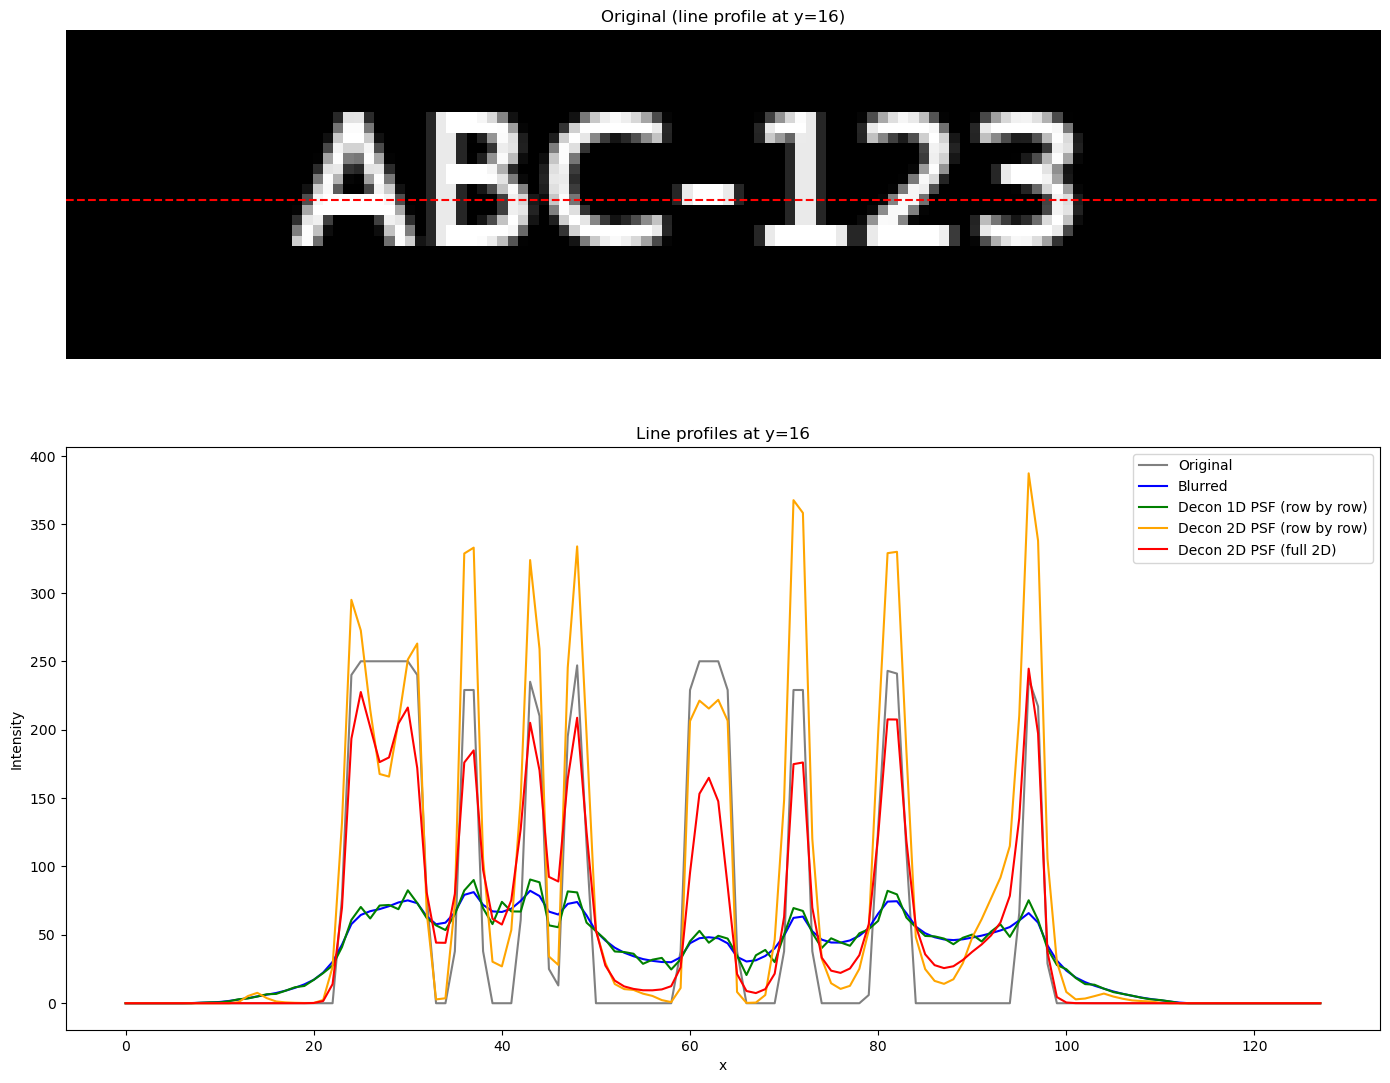

In [ ]:
y = 16

images = [im, blurred, decon_image_1d_1d, decon_image_1d_2d, decon_2d]
titles = ['Original', 'Blurred', 'Decon 1D PSF (row by row)', 'Decon 2D PSF (row by row)', 'Decon 2D PSF (full 2D)']
colors = ['gray', 'blue', 'green', 'orange', 'red']

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Top: original image with line location
axes[0].imshow(im, cmap='gray', interpolation='nearest')
axes[0].axhline(y=y, color='red', linewidth=1.5, linestyle='--')
axes[0].set_title(f'Original (line profile at y={y})')
axes[0].axis('off')

# Add PSF as a small inset in the corner of the image axes
inset_ax = axes[0].inset_axes([0.78, 0.02, 0.20, 0.45])  # slightly bigger
inset_ax.imshow(psf_2d_norm, cmap='hot', interpolation='nearest')
inset_ax.set_title('PSF', fontsize=9, color='white', pad=2)
inset_ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
for spine in inset_ax.spines.values():
    spine.set_edgecolor('white')

# Bottom: all line profiles overlaid
for img, title, color in zip(images, titles, colors):
    axes[1].plot(img[y], color=color, label=title)
axes[1].set_title(f'Line profiles at y={y}')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Intensity')
axes[1].legend()

plt.tight_layout()
plt.show()